In [2]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import time
import datetime

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [ ]:
# ============================
# 1. SIMULATE DATA WITH Z MATRIX
# ============================

def generate_simulated_data(n_units=500, n_obs=50, seed=42):
    """
    Generates synthetic Hierarchical Multinomial Logit (HMNL) choice data.

    This function simulates a dataset where individuals (units) make repeated 
    discrete choices among alternatives. Individual-level preferences are 
    influenced by demographic covariates (Z) via a global parameter matrix (Delta).

    Args:
        n_units (int, optional): Number of distinct individuals/decision-makers. 
            Defaults to 300.
        n_obs (int, optional): Number of choice tasks observed per individual. 
            Defaults to 50.
        seed (int, optional): Random seed for reproducibility. Defaults to 42.

    Returns:
        dict: A dictionary containing the simulated dataset as JAX arrays:
            - 'X': Design matrix of choice attributes (N_total, n_alts, n_params).
            - 'y': Array of observed choices (N_total,).
            - 'Z': Demographic covariate matrix (n_units, n_demos).
            - 'unit_idx': Array mapping each observation to its unit (N_total,).
            - 'n_units': Integer count of units.
            - 'n_params': Integer count of parameters (k_dim).
            - 'n_alts': Integer count of choice alternatives.
            - 'n_z': Integer count of demographic variables.
            - 'TRUE_DELTA': Ground truth for the global demographic effects.
            - 'TRUE_SIGMA': Ground truth for the individual-level variance.
            - 'TRUE_BETA': Ground truth for the individual-level parameters.
    """
    np.random.seed(seed)
    
    # Define dimensions
    n_alts = 4
    n_params = 4  
    n_demos = 2   
    
    # A. Generate Demographic Data (Z)
    # Z consists of a base intercept (ones) and one random continuous demographic
    Z = np.column_stack([
        np.ones(n_units),               
        np.random.normal(0, 1, n_units) 
    ])
    
    # Define True Population Parameters
    # TRUE Global Parameters (Delta): Maps demographics to preferences
    Delta_true = np.array([
        [ 1.5,  0.5, -0.5, -2.0],  # Intercept row (base population mean)
        [ 0.8, -0.3,  0.0,  0.5]   # Demographic 1 row (effect of demo on preferences)
    ])
    
    # TRUE Variance (Sigma): Heterogeneity/variance around the population mean
    Sigma_true = np.diag([1, 0.5, 1.5, 0.5]) 
    
    # Generate Individual-Level Parameters (Beta)
    beta_true = np.zeros((n_units, n_params))
    
    for i in range(n_units):
        # The mean for individual 'i' is shifted by their demographic traits
        mu_i = Z[i] @ Delta_true
        # Draw individual parameters from the multivariate normal distribution
        beta_true[i] = np.random.multivariate_normal(mu_i, Sigma_true)
        
    # Simulate Choice Tasks and Observations
    X_list, y_list, unit_idx_list = [], [], []
    
    for i in range(n_units):
        for t in range(n_obs):
            # Build the design matrix for this specific choice task
            X_it = np.zeros((n_alts, n_params))
            
            # Alternative-Specific Constants for alternatives 1, 2, and 3
            # (Alternative 0 is implicitly the reference/base case)
            X_it[1, 0] = 1.0
            X_it[2, 1] = 1.0
            X_it[3, 2] = 1.0
            
            # Continuous attribute (e.g., 'Price') varies uniformly across all alternatives
            X_it[:, 3] = np.random.uniform(1.0, 5.0, n_alts)
            
            # Calculate utility for each alternative (U = X * beta)
            U_it = X_it @ beta_true[i]
            
            # Convert utilities to probabilities using the softmax function
            probs = np.exp(U_it) / np.sum(np.exp(U_it))
            
            # Simulate a discrete choice based on those probabilities
            y_it = np.random.choice(n_alts, p=probs)
            
            # Store the data
            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)
            
    # Return as JAX-compatible arrays along with metadata and true parameters
    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units": n_units,
        "n_params": n_params,
        "n_alts": n_alts,
        "n_z": n_demos,
        "TRUE_DELTA": Delta_true,
        "TRUE_SIGMA": Sigma_true,
        "TRUE_BETA": beta_true
    }

# ============================
# Execution & Setup Variables
# ============================
print("Simulating data...")
data_sim = generate_simulated_data()

k_dim = data_sim["n_params"]
param_names = ["Brand 1", "Brand 2", "Brand 3", "Price"]
demo_names = ["Base (Intercept)", "Demographic 1"]

Simulating data...


In [39]:
# ============================
# 2. MODEL BUILDING & INFERENCE
# ============================

def make_wishart(df, scale_tril):
    """
    Constructs a Wishart distribution parameterized by a Cholesky factor.

    Args:
        df (float or array-like): The degrees of freedom for the Wishart distribution.
        scale_tril (array-like): The lower triangular Cholesky factor of the scale matrix.

    Returns:
        tfd.WishartTriL: A TensorFlow Probability Wishart distribution object.
    """
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )


def make_mvn_precision(loc, precision_factor):
    """
    Constructs a Multivariate Normal (MVN) distribution using a precision factor.

    Args:
        loc (array-like): The mean (location) vector of the distribution.
        precision_factor (array-like): The lower triangular matrix used as the 
            factor for the precision matrix.

    Returns:
        tfde.MultivariateNormalPrecisionFactorLinearOperator: An MVN distribution 
        parameterized by precision rather than covariance.
    """
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )


def build_unified_hmnl_model(data_dict, A_val=0.01):
    """
    Builds a unified Hierarchical Multinomial Logit (HMNL) model using Liesel.

    This function sets up the priors, latent variables, and likelihood for the HMNL 
    model. It dynamically handles the presence or absence of demographic covariates ('Z').

    Args:
        data_dict (dict): A dictionary containing the dataset. Expected keys include:
            - 'n_params': Number of parameters (k_dim).
            - 'n_units': Number of distinct units/individuals.
            - 'X': Design matrix of observations.
            - 'y': Observed categorical choices.
            - 'unit_idx': Mapping of observations to specific units.
            - 'Z' (optional): Matrix of demographic characteristics.
        A_val (float, optional): Scaling factor for the precision matrix prior. 
            Defaults to 0.01.

    Returns:
        lsl.Model: A compiled Liesel model containing the observed node `y`.
    """
    # Extract dimensions and flags from data dictionary
    k_dim = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    has_Z = data_dict.get("Z") is not None

    # Setup Covariance Prior (Wishart)
    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)

    # Cholesky factor of the inverse covariance matrix
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(
            make_wishart,
            df=nu_val,
            scale_tril=Vinv_chol_val
        ),
        name="sigma_inv_chol"
    )
    
    # Transform to latent space for efficient sampling
    sigma_inv_chol_latent = sigma_inv_chol.transform(
        tfb.FillScaleTriL(), 
        name="sigma_inv_chol_latent"
    )
    
    # Calculate the precision factor for the population mean
    mu_prec_factor = lsl.Var.new_calc(
        lambda L: jnp.sqrt(A_val) * L, 
        L=sigma_inv_chol, 
        name="mu_prec_factor"
    )

    # Setup Global Parameters (with or without Demographics)
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        
        # Delta captures the effect of demographic covariates
        global_param = lsl.Var.new_param(
            value=jnp.zeros((n_demos, k_dim)),
            distribution=lsl.Dist(
                make_mvn_precision, 
                loc=jnp.zeros(k_dim), 
                precision_factor=mu_prec_factor
            ),
            name="Delta"
        )
        
        # Individual-level means are shifted by their demographic traits
        loc_var = lsl.Var.new_calc(
            lambda z, delta: jnp.dot(z, delta), 
            z=Z_var, 
            delta=global_param, 
            name="beta_loc"
        )
    else:
        # Standard global mean across the population
        global_param = lsl.Var.new_param(
            value=jnp.zeros(k_dim),
            distribution=lsl.Dist(
                make_mvn_precision, 
                loc=jnp.zeros(k_dim), 
                precision_factor=mu_prec_factor
            ),
            name="mu"
        )
        loc_var = global_param

    # Setup Individual-Level Parameters
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(
            make_mvn_precision, 
            loc=loc_var, 
            precision_factor=sigma_inv_chol
        ),
        name="beta_i"
    )

    # Setup Likelihood (Categorical Logits)
    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    
    # Expand unit-level parameters to match the observation array size
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], 
        b=beta_i, 
        idx=idx_var, 
        name="beta_expanded"
    )
    
    # Calculate logits using batched dot product via einsum
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
        x=X_var, 
        b=beta_expanded, 
        name="logits"
    )
    
    # Final observed categorical variable
    y_var = lsl.Var.new_obs(
        data_dict["y"], 
        distribution=lsl.Dist(tfd.Categorical, logits=logits), 
        name="y"
    )

    return lsl.Model([y_var])


def run_unified_inference(model, data_dict, chains=4, warmup=1000, posterior=5000, seed=123):
    """
    Configures and runs MCMC inference using the No-U-Turn Sampler (NUTS) via Goose.

    Args:
        model (lsl.Model): The constructed Liesel model to sample from.
        data_dict (dict): The dataset dictionary, used here to infer the target 
            global parameter node.
        chains (int, optional): Number of MCMC chains to run. Defaults to 1.
        warmup (int, optional): Number of warmup/burn-in samples per chain. 
            Defaults to 1000.
        posterior (int, optional): Number of posterior samples to draw per chain. 
            Defaults to 5000.
        seed (int, optional): Random seed for reproducibility. Defaults to 123.

    Returns:
        tuple: A 2-element tuple containing:
            - The full Goose results object.
            - A dictionary or array of extracted posterior samples.
    """
    # Initialize the Engine Builder
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)
    
    # Determine the global parameter node to target based on demographics inclusion
    global_param_name = "Delta" if data_dict.get("Z") is not None else "mu"
    
    # Add NUTS kernels for specific latent and parameter variables
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel([global_param_name])) 
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))
    
    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print(f"Starting NUTS Sampling (Targeting: {global_param_name})...")
    
    # Build and execute the sampling engine
    engine = eb.build()
    engine.sample_all_epochs()
    
    return engine.get_results(), engine.get_results().get_posterior_samples()

In [40]:
# ============================
# 3. RUN MODEL
# ============================
print("Building Unified Model...")
model_sim = build_unified_hmnl_model(data_sim)

start_time = time.time()
res_sim, liesel_samples = run_unified_inference(model_sim, data_sim, chains=4, warmup=1000, posterior=5000)

formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {formatted_time}")

Building Unified Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling (Targeting: Delta)...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:19<00:00,  6.38s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 5, 4, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2, 1, 3, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 425.30chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1, 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1, 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:18:57


In [1]:
# ==============================
# 4. DATA PROCESSING & RESHAPING
# ==============================
print("Standardizing array shapes for comparison...")

n_demos = data_sim["n_z"]

# Prepare Liesel Arrays
liesel_delta_full = liesel_samples["Delta"].reshape(-1, n_demos, k_dim)
liesel_mu = liesel_delta_full[:, 0, :]  # Base intercepts

# Prepare True Arrays
true_delta = data_sim["TRUE_DELTA"]
true_mu = true_delta[0, :]

print(f"Liesel Shapes -> Mu: {liesel_mu.shape}, Delta: {liesel_delta_full.shape}")
print(f"True Shapes   -> Mu: {true_mu.shape},   Delta: {true_delta.shape}")

Standardizing array shapes for comparison...


NameError: name 'data_sim' is not defined

In [ ]:
# ==========================================
# 7. MCMC DIAGNOSTICS & TRACE PLOTS
# ==========================================
print("\n=== MCMC Convergence Summary ===")
# Create summary for numerical diagnostics 
summary = gs.Summary(res_sim)
display(summary)


=== MCMC Convergence Summary ===


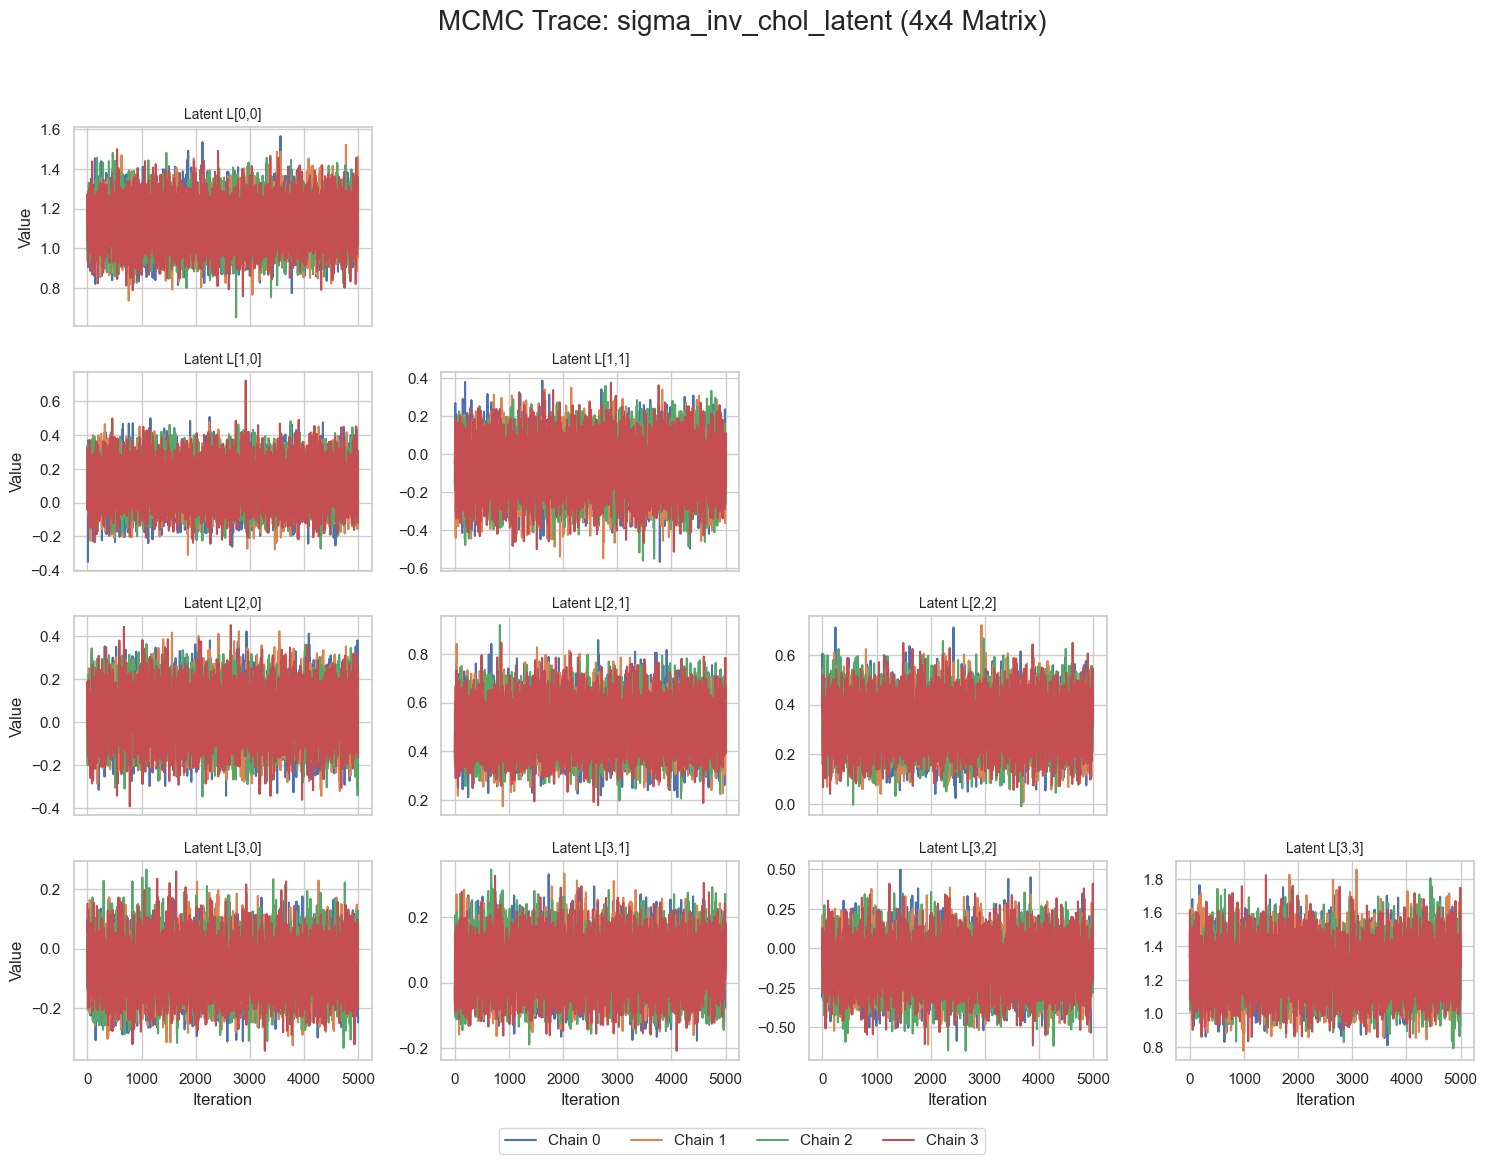

In [ ]:
def plot_cholesky_traces(samples_dict, k_dim, param_name="sigma_inv_chol_latent", figsize=(15, 12)):
    """
    Plots MCMC trace plots for the latent parameters of a Cholesky factor matrix.
    
    This function dynamically generates a k_dim x k_dim grid, plotting the 
    MCMC chains for the lower triangular elements and hiding the upper triangular 
    axes where no parameters exist.

    Args:
        samples_dict (dict): A dictionary or similar data structure containing 
            the posterior samples.
        k_dim (int): The dimensionality of the original square matrix (e.g., 4 
            for a 4x4 matrix).
        param_name (str, optional): The key in the samples dictionary corresponding 
            to the latent Cholesky parameters. Defaults to "sigma_inv_chol_latent".
        figsize (tuple, optional): The dimensions of the figure (width, height). 
            Defaults to (15, 12).

    Returns:
        tuple: A tuple containing the matplotlib Figure and a 2D array of Axes objects.
    """
    # Extract the latent samples
    latent_samples = samples_dict[param_name]
    n_chains, n_draws, n_latent = latent_samples.shape

    # Dynamically create grid based on k_dim
    fig, axes = plt.subplots(k_dim, k_dim, figsize=figsize, sharex=True, sharey=False)
    
    # Handle the edge case where k_dim == 1 (axes is not a 2D array)
    if k_dim == 1:
        axes = np.array([[axes]])

    # Counter to keep track of which latent parameter we are plotting
    latent_idx = 0

    for i in range(k_dim):       # Rows
        for j in range(k_dim):   # Columns
            ax = axes[i, j]
            
            # In a lower triangular matrix, parameters exist only where i >= j
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(
                        latent_samples[chain, :, latent_idx],
                        label=f"Chain {chain}"
                    )
                
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                # Hide axes for the upper triangle where there is no data
                ax.axis('off')
            
            # Grid and formatting
            ax.grid(True)
            
            # Only add x-labels to the bottom-most active subplots
            if i == k_dim - 1 or (i >= j and i + 1 < k_dim and i + 1 < j): 
                ax.set_xlabel("Iteration")
                
            # Only add y-labels to the first column
            if j == 0:
                ax.set_ylabel("Value")

    # Add a single legend for the whole figure
    # Extract handles from the first valid plot (0,0)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center', 
        ncol=n_chains, 
        bbox_to_anchor=(0.5, 0.02)
    )

    plt.suptitle(
        f"MCMC Trace: {param_name} ({k_dim}x{k_dim} Matrix)", 
        fontsize=20
    )
    
    # Adjust layout to make room for the legend at the bottom and title at the top
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    
    return fig, axes

# Call the function using generated samples and dimensions
fig, axes = plot_cholesky_traces(
    samples_dict=liesel_samples, 
    k_dim=k_dim
)


Recovering Covariance Matrix (Sigma)...


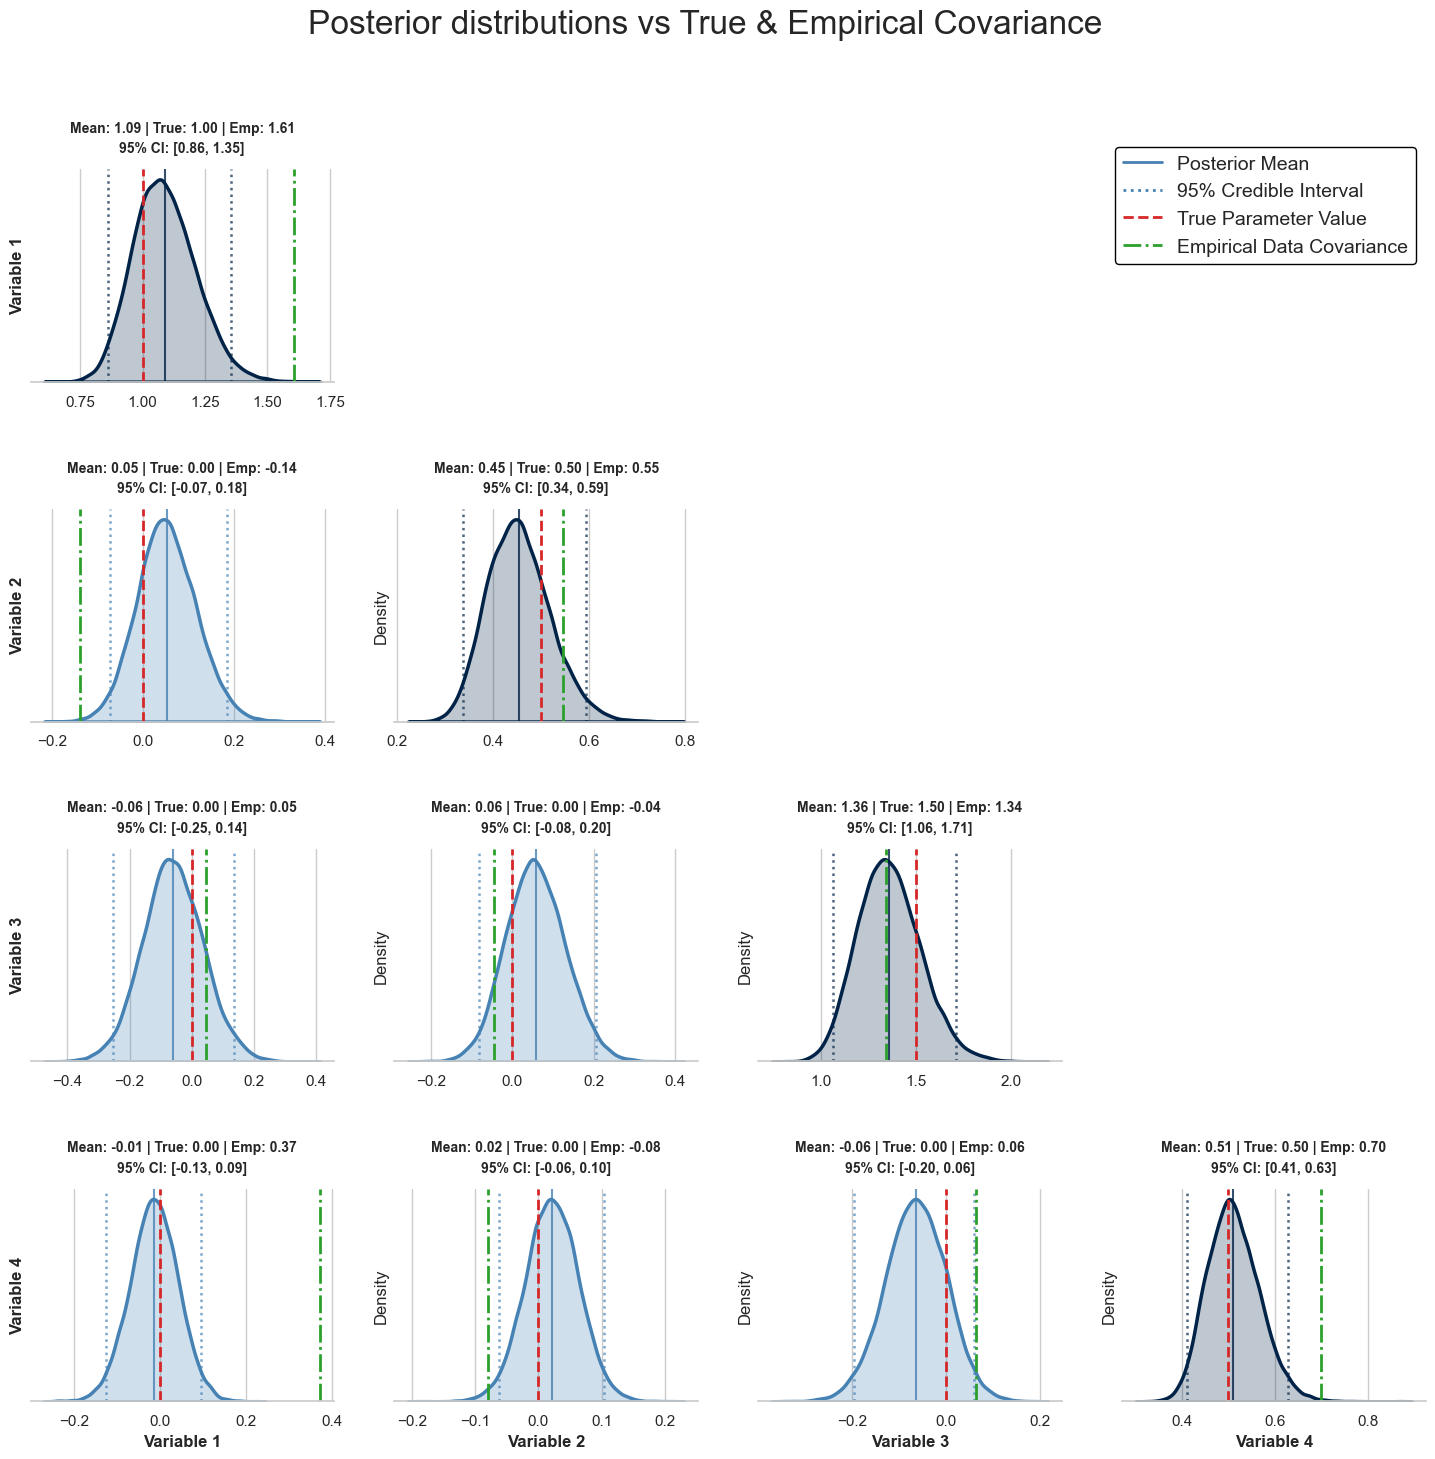

In [ ]:
# ==========================================
# 9. COVARIANCE RECOVERY & PLOTTING
# ==========================================
from matplotlib.lines import Line2D
print("\nRecovering Covariance Matrix (Sigma)...")

# Setup the bijector (must match the one in the model)
bijector = tfb.FillScaleTriL()

# Function to turn 1D vector -> Lower Triangular Matrix -> Covariance Matrix
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Vectorize across chains and draws
v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))

# Extract the latent samples from your previous Liesel run
latent_samples = liesel_samples["sigma_inv_chol_latent"]
sigma_samples = v_latent_to_sigma(latent_samples)

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    
    # Create the figure and axes
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    # Loop through the grid
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # Stats Calculation
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            # Plot KDE
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # Reference Lines
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            # Textual Labels
            stats_str = " | ".join(title_parts)
            title_str = (
                f"{stats_str}\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    # --- NEW: FIGURE-LEVEL FLOATING LEGEND ---
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance')
    ]
    
    # We use fig.legend instead of ax.legend
    fig.legend(
        handles=legend_elements, 
        loc='upper right',           # Anchor point on the legend box
        bbox_to_anchor=(0.9, 0.9), # (x, y) coordinates for the anchor relative to the whole figure (0 to 1)
        fontsize=14, 
        frameon=True,        
        edgecolor='black',    
        framealpha=1,        
        fancybox=True        
    )

    plt.suptitle("Posterior distributions vs True & Empirical Covariance", 
                 fontsize=24, y=0.98, fontweight='light')
    
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Calculate Empirical Covariance from the true Betas generated in step 1
empirical_sigma = jnp.cov(data_sim["TRUE_BETA"], rowvar=False)

# Run the plot
plot_final_covariance_complete(sigma_samples, data_sim["TRUE_SIGMA"], empirical_sigma)


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


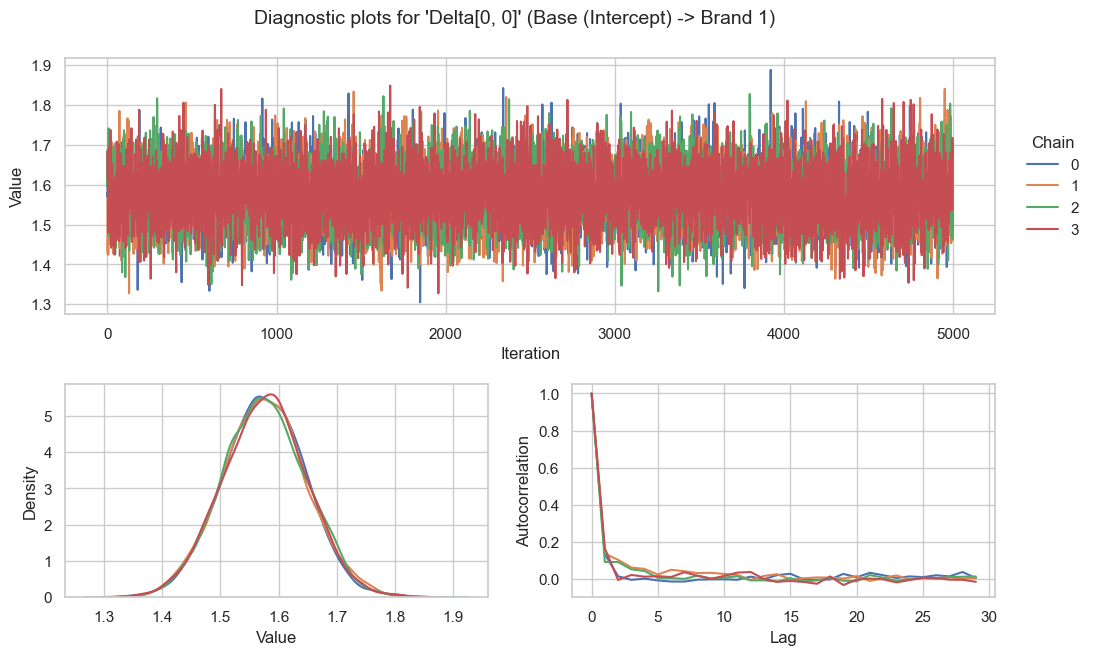

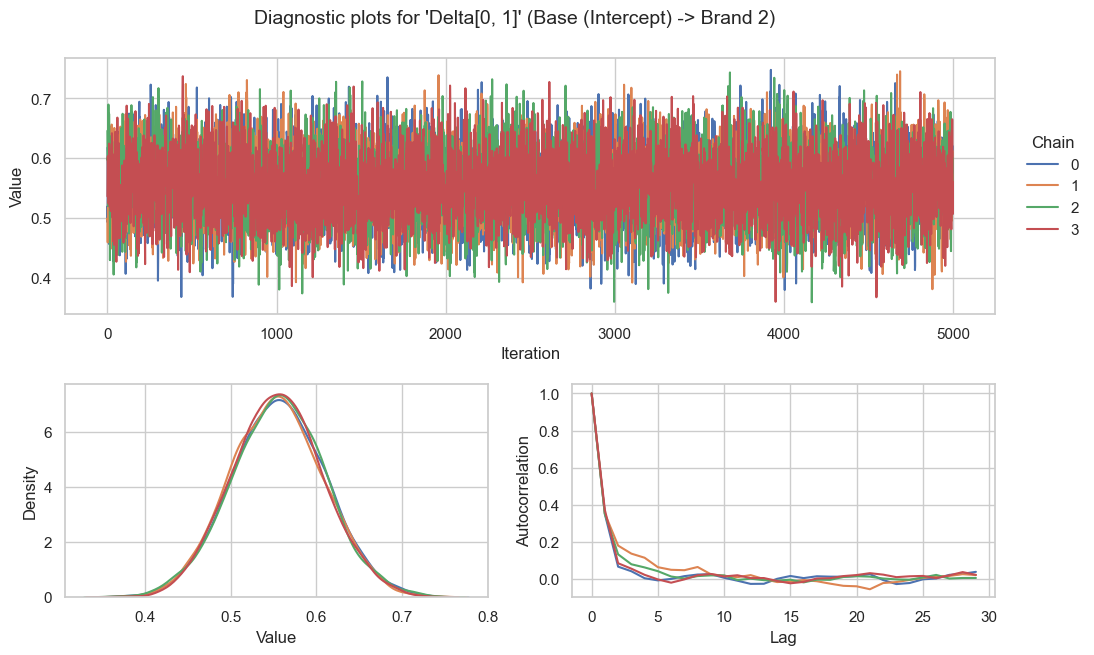

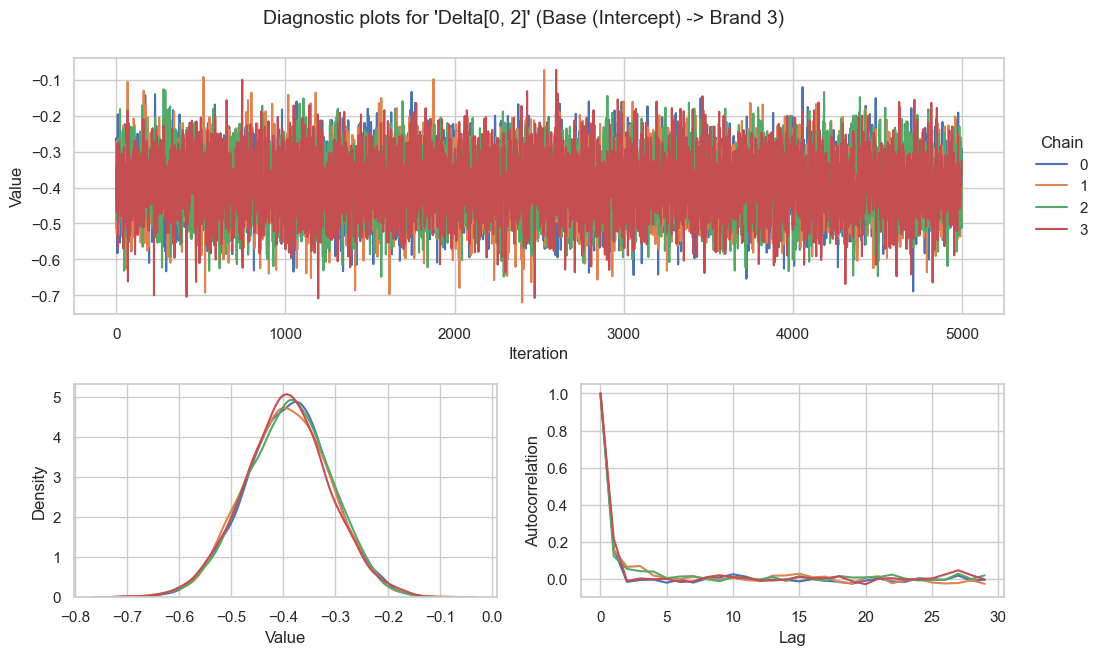

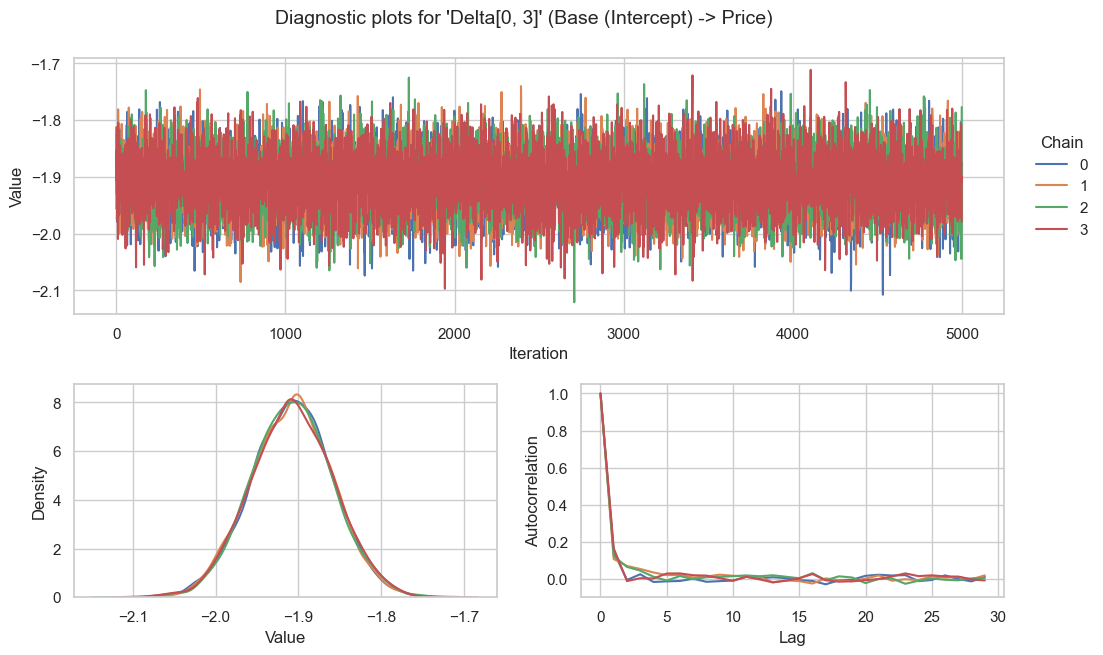

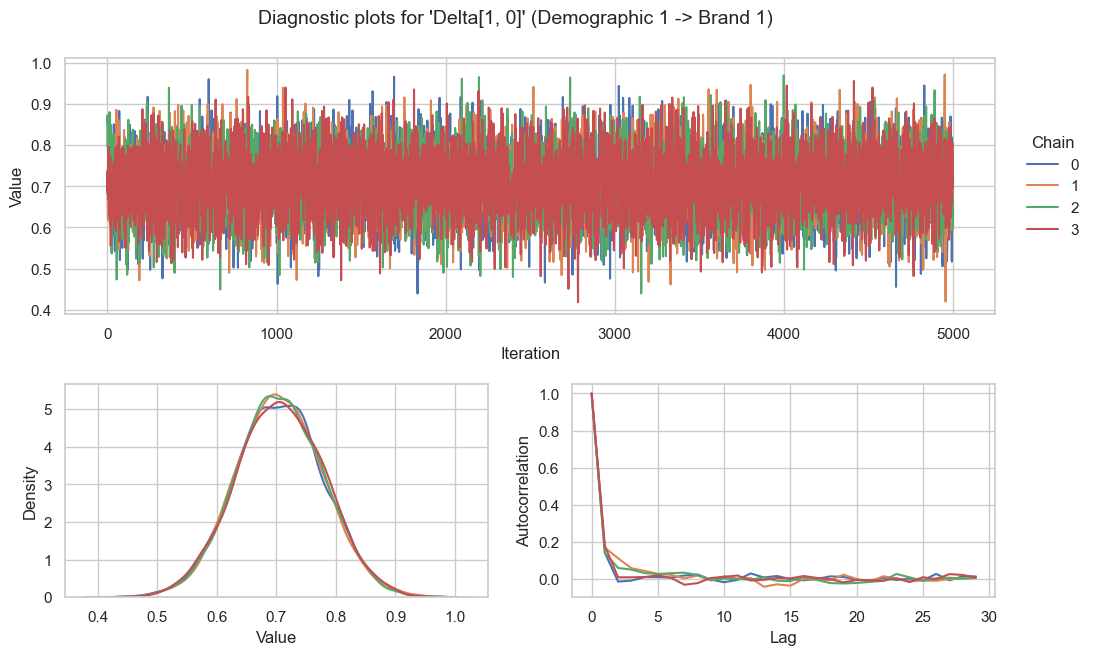

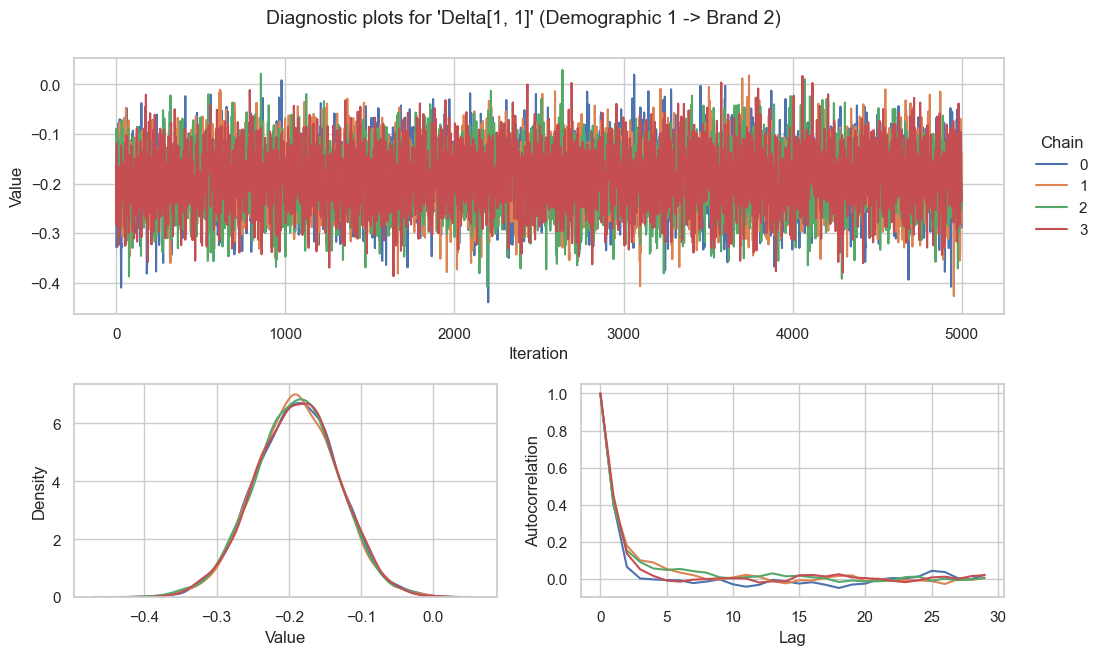

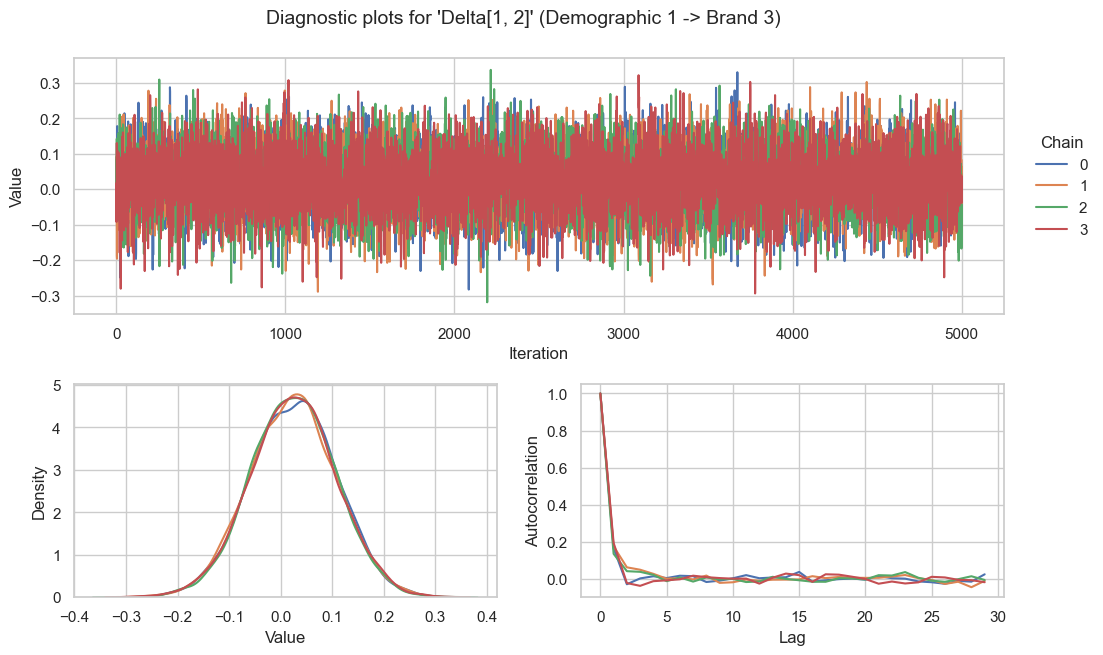

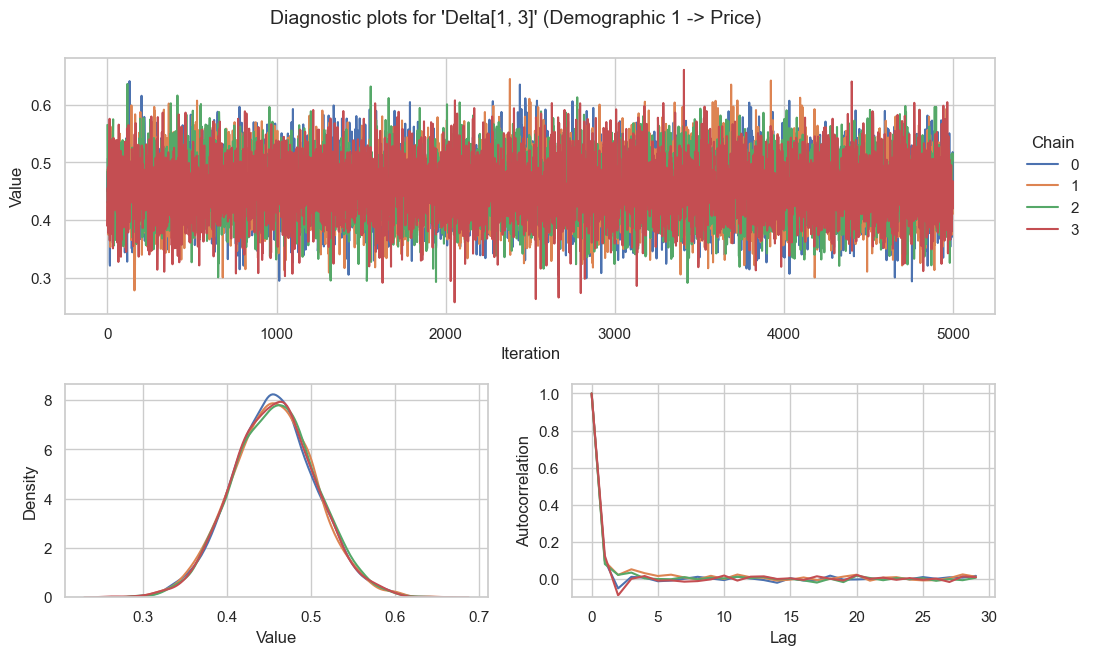

In [ ]:
# ============================================
# DETAILED DIAGNOSTICS: GOOSE-STYLE RECREATION
# ============================================

def compute_acf(x, nlags=30):
    """Computes the autocorrelation function for a 1D array."""
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered**2)
    if norm == 0:
        return np.zeros(nlags)
    
    # Compute full cross-correlation and extract positive lags
    acf = np.correlate(x_centered, x_centered, mode='full')
    acf = acf[acf.size // 2:] / norm
    return acf[:nlags]

def plot_goose_style_diagnostics(delta_samples, demo_idx, param_idx, demo_name, param_name, n_lags=30):
    """
    Recreates the Liesel Goose 3-panel diagnostic plot layout 
    (Trace, Density, ACF) for a specific matrix element.
    """
    n_chains = delta_samples.shape[0]
    
    # Set up the figure and grid
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostic plots for 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})", 
        fontsize=14, y=0.95
    )
    
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
    
    # Trace Plot (Top row, spanning both columns)
    ax_trace = fig.add_subplot(gs[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_samples[chain, :, demo_idx, param_idx], label=f"{chain}")
    
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    # Replicate the exact legend placement from the Goose plot
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    
    # Density Plot (Bottom Left)
    ax_dens = fig.add_subplot(gs[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_samples[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
        
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)
    
    # Autocorrelation Plot (Bottom Right)
    ax_acf = fig.add_subplot(gs[1, 1])
    for chain in range(n_chains):
        acf_vals = compute_acf(delta_samples[chain, :, demo_idx, param_idx], nlags=n_lags)
        ax_acf.plot(acf_vals, alpha=1)
        
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    
    plt.show()

# Run the plotting loop for all elements in the Delta matrix
print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")

# Pull variables from previous scope
delta_samples = liesel_samples["Delta"]
n_chains, n_draws, n_demos, k_dim = delta_samples.shape

for i in range(n_demos):
    for j in range(k_dim):
        plot_goose_style_diagnostics(
            delta_samples, 
            demo_idx=i, 
            param_idx=j, 
            demo_name=demo_names[i], 
            param_name=param_names[j]
        )

In [ ]:
# ============================================
# 5. GLOBAL PARAMETERS: BASELINE MEANS & DELTA
# ============================================

def create_summary_table(t_mu, l_mu, p_names):
    return pd.DataFrame({
        'Parameter': p_names,
        'True_Value': t_mu,
        'Liesel_Mean': l_mu.mean(axis=0),
        'Diff_Abs': np.abs(t_mu - l_mu.mean(axis=0)),
        'Liesel_Std': l_mu.std(axis=0)
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means) Summary Table ===")
display(create_summary_table(true_mu, liesel_mu, param_names))

def generate_delta_table(delta_draws, p_names, d_names):
    mean, std = np.mean(delta_draws, axis=0), np.std(delta_draws, axis=0)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]: .2f} ({std[i, j]:.2f})"
    return df

def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    """Calculates Absolute Differences between True Delta and Liesel Delta means."""
    l_mean = np.mean(l_delta, axis=0)
    diff_mean = np.abs(t_delta - l_mean)
    
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]: .3f}"
    return df

print("\n=== True distribution of Delta (Ground Truth) ===")
true_df = pd.DataFrame(true_delta, index=demo_names, columns=param_names)
display(true_df)

print("\n=== Posterior distribution of Delta (Liesel) ===")
display(generate_delta_table(liesel_delta_full, param_names, demo_names))

print("\n=== ABSOLUTE DIFFERENCE in Delta (|True - Liesel|) ===")
display(generate_delta_diff_table(true_delta, liesel_delta_full, param_names, demo_names))


=== Global Parameters (Baseline Means) Summary Table ===


,True_Value,Liesel_Mean,Diff_Abs,Liesel_Std
Parameter,,,,
Brand 1,1.5,1.5761,0.0761,0.0718
Brand 2,0.5,0.5555,0.0555,0.0543
Brand 3,-0.5,-0.3915,0.1085,0.0819
Price,-2.0,-1.9079,0.0921,0.0493



=== True distribution of Delta (Ground Truth) ===


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),1.5,0.5,-0.5,-2.0
Demographic 1,0.8,-0.3,0.0,0.5



=== Posterior distribution of Delta (Liesel) ===


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),1.58 (0.07),0.56 (0.05),-0.39 (0.08),-1.91 (0.05)
Demographic 1,0.71 (0.07),-0.19 (0.06),0.02 (0.08),0.46 (0.05)



=== ABSOLUTE DIFFERENCE in Delta (|True - Liesel|) ===


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),0.076,0.055,0.109,0.092
Demographic 1,0.094,0.111,0.024,0.044


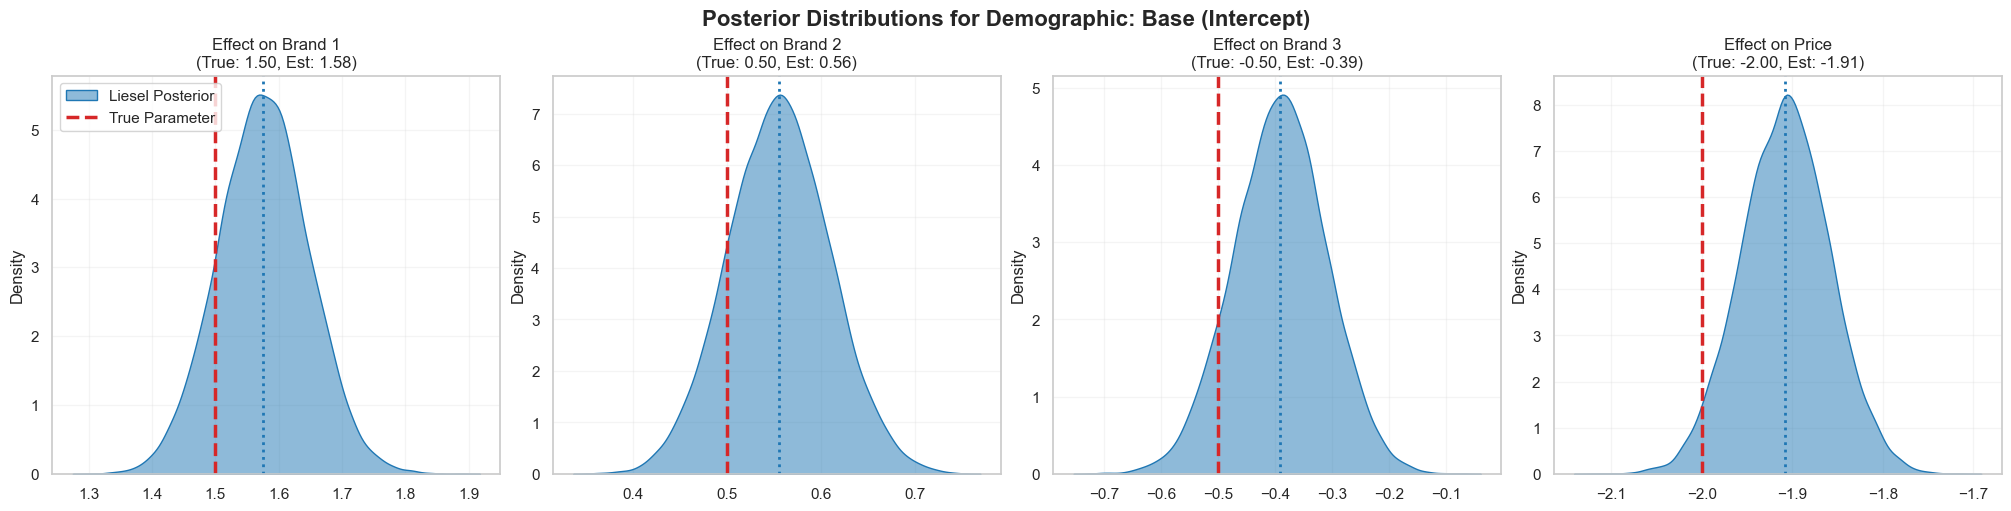

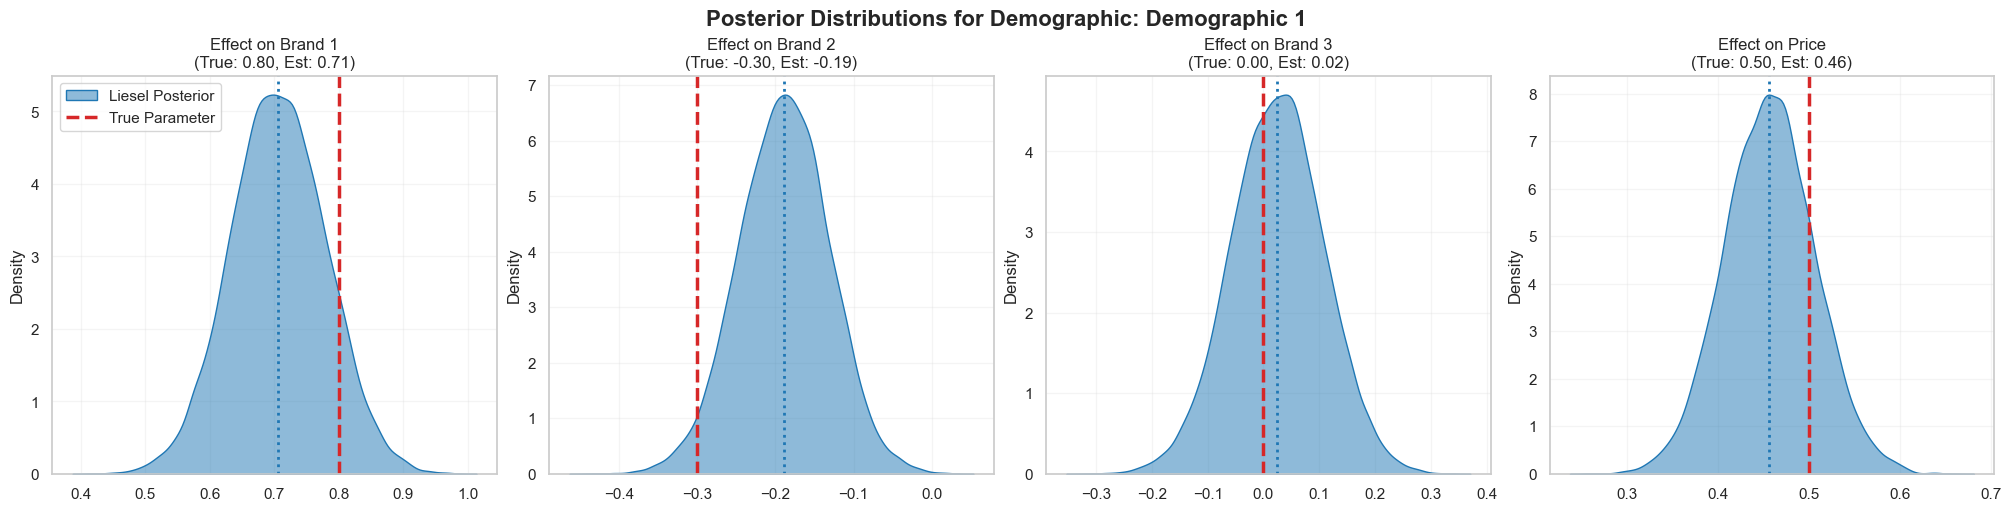

In [ ]:
# ==========================================
# 6. ANALYTICS & DIAGNOSTICS PLOTS
# ==========================================

def plot_delta_distributions(t_delta, l_delta, demo_idx, demo_name, param_names):
    """
    Plots the Liesel posterior distributions vs the True Ground Truth parameter.
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
    fig.suptitle(f"Posterior Distributions for Demographic: {demo_name}", fontsize=16, fontweight='bold')
    
    for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
        l_vals = l_delta[:, demo_idx, i]
        t_val = t_delta[demo_idx, i]
        
        # Plot Liesel Posterior
        sns.kdeplot(l_vals, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Liesel Posterior")
        
        # Plot True Value (Red Line)
        ax.axvline(t_val, color="#d62728", linestyle="--", lw=2.5, label="True Parameter")
        ax.axvline(np.mean(l_vals), color="#1f77b4", linestyle=":", lw=2)
        
        ax.set_title(f"Effect on {param}\n(True: {t_val:.2f}, Est: {np.mean(l_vals):.2f})")
        ax.grid(True, alpha=0.2)
        if i == 0: ax.legend(loc="upper left")

    plt.show()

# Plot distributions for Base Intercepts (Index 0)
plot_delta_distributions(
    true_delta, 
    liesel_delta_full, 
    demo_idx=0, 
    demo_name="Base (Intercept)", 
    param_names=param_names
)

# Plot distributions for Demographic 1 (Index 1)
plot_delta_distributions(
    true_delta, 
    liesel_delta_full, 
    demo_idx=1, 
    demo_name="Demographic 1", 
    param_names=param_names
)